<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Learning Curves and Ablation Studies

_Prepared by Claudia Zendejas-Morales_

Single best-score tables hide too much about how a model actually behaves. A fair QML evaluation should also ask how performance changes as more training data are provided, how sensitive the model is to specific design choices, and whether an apparent improvement remains stable across repeated runs. Learning curves address the first question by tracking performance as the training size grows. Ablation studies address the second by varying one factor at a time while the rest of the pipeline stays fixed. In QML, both tools are especially important because conclusions can change substantially with the encoding choice, ansatz depth, shot budget, and random seed.


## Learning curves as size-dependent evidence

Let
$$
D = \{(\vec{x}^{\,j}, y^j)\}_{j=1}^{M}
$$
and let
$$
D_{\mathrm{train}}^{(u)} \subset D_{\mathrm{train}}, \qquad u \in \{1,\dots,U\}, \qquad |D_{\mathrm{train}}^{(u)}| = M_u
$$
be a sequence of training subsets of increasing size. Here, $u$ indexes the position along the learning curve, and $M_u$ denotes the number of training samples used at that point of the curve.

If $a_{\mathrm{train}}^{(k)}(M_u)$ and $a_{\mathrm{val}}^{(k)}(M_u)$ denote the values of any chosen training and validation evaluation metric obtained in repeated run $k$ at training size $M_u$, then the corresponding mean summaries across $K$ repeated runs are
$$
\bar a_{\mathrm{train}}(M_u)=\frac{1}{K}\sum_{k=1}^{K} a_{\mathrm{train}}^{(k)}(M_u), \qquad
\bar a_{\mathrm{val}}(M_u)=\frac{1}{K}\sum_{k=1}^{K} a_{\mathrm{val}}^{(k)}(M_u)
$$
The corresponding generalization gap for that metric is
$$
\Delta_{\mathrm{gen}}(M_u)=\bar a_{\mathrm{train}}(M_u)-\bar a_{\mathrm{val}}(M_u)
$$
This helps separate underfitting, overfitting, and simple data scarcity.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>A learning curve is diagnostic evidence, not a proof of advantage.</b> If both curves stay low, the model or representation may be too weak. If training is much higher than validation, the model may be overfitting. If the gap shrinks as more data are added, the model may simply need more data.</div>

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/learning-curves-diagnostics.png" alt="Three common learning-curve patterns" width="1000"/>
</p>

The left panel illustrates a high-bias or underfitting regime: both curves stay relatively low and close to each other, so adding more data does not substantially improve the overall level of performance. The middle panel illustrates overfitting at small training sizes: the training score starts much higher than the validation score, which indicates a large generalization gap, and that gap narrows as more training data are provided. The right panel shows a healthier pattern: both curves are already reasonably high, and the validation score approaches the training score as the training-set size grows. In all three panels, the solid line denotes the training score and the dashed line denotes the validation score.


## Example 1: Learning curves on a matched breast-cancer representation

The case study uses the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html">breast cancer dataset</a> with train-only preprocessing at each training size: standardization, two-component <a href="https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html">PCA</a>, and rescaling into $[0,\pi]$. The same two-feature representation is then given to a small two-qubit variational model and to matched classical baselines.

If $\tilde{\vec{x}}^{\,j} \in [0,\pi]^2$ denotes the two-dimensional preprocessed feature vector and $e$ denotes the encoding choice, then the quantum model used in the study can be written as
$$
|\psi_{\mathrm{in}}(\tilde{\vec{x}}^{\,j}; e)\rangle = U_F^{(e)}(\tilde{\vec{x}}^{\,j})|0\rangle^{\otimes 2},
\qquad
|\psi_{\mathrm{out}}(\tilde{\vec{x}}^{\,j}; e, \boldsymbol{\theta}, L)\rangle = U_A^{(L)}(\boldsymbol{\theta})|\psi_{\mathrm{in}}(\tilde{\vec{x}}^{\,j}; e)\rangle
$$
with scalar readout
$$
s^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\tilde{\vec{x}}^{\,j}; e, \boldsymbol{\theta}, L)| Z_0 |\psi_{\mathrm{out}}(\tilde{\vec{x}}^{\,j}; e, \boldsymbol{\theta}, L)\rangle
$$
probability map
$$
p^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta}) = \frac{1 + s^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})}{2}
$$
and prediction rule
$$
\hat y_{\mathrm{Q}}(\tilde{\vec{x}}^{\,j}) = \mathbf{1}\!\left[p^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta}) \geq \frac{1}{2}\right]
$$

The next cell defines reusable train-only preprocessing, a lightweight variational classifier, exact and shot-based readout simulation, and the helper functions used in the examples and embedded tasks.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why keep the quantum code lightweight here?</b> As in Section 3.4, the quantum part of the case study is implemented with hand-written linear algebra in NumPy so that repeated runs, learning-curve sweeps, and ablation grids do not become unnecessarily slow. A framework implementation would add overhead at each repeated circuit evaluation, which would be especially noticeable in this notebook.</div>

**Framework note.** Qiskit Machine Learning models such as <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkClassifier.html"><code>NeuralNetworkClassifier</code></a> and <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html"><code>VQC</code></a> can participate in learning-curve or ablation workflows through their scikit-learn-compatible <code>fit</code>, <code>predict</code>, and <code>score</code> methods, but Qiskit does not currently provide a dedicated learning-curve or ablation API in its core QML estimators. PennyLane likewise does not currently provide a dedicated core API for learning curves or ablation studies; these repeated sweeps are usually orchestrated around a <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html"><code>qml.qnn.TorchLayer</code></a> or a <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>QNode</code></a> using the selected interface.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

np.set_printoptions(precision=4, suppress=True)

I2 = np.eye(2, dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
CNOT01 = np.array(
    [[1, 0, 0, 0],
     [0, 1, 0, 0],
     [0, 0, 0, 1],
     [0, 0, 1, 0]],
    dtype=complex,
)
Z0 = np.kron(Z, I2)
PSI0 = np.array([1, 0, 0, 0], dtype=complex)


def ry_matrix(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -s], [s, c]], dtype=complex)


CNOT10 = np.array(
    [[1, 0, 0, 0],
     [0, 0, 0, 1],
     [0, 0, 1, 0],
     [0, 1, 0, 0]],
    dtype=complex,
)

ENCODING_LABELS = {
    'angle_y': 'Angle (RY-RY)',
    'angle_yz': 'Mixed-axis (RY-RZ)',
    'entangled': 'Entangled feature map',
}


def rz_matrix(theta):
    return np.array(
        [[np.exp(-1j * theta / 2.0), 0.0], [0.0, np.exp(1j * theta / 2.0)]],
        dtype=complex,
    )


def feature_state(sample, encoding='angle_y'):
    if encoding == 'angle_y':
        return np.kron(ry_matrix(sample[0]), ry_matrix(sample[1])) @ PSI0
    if encoding == 'angle_yz':
        return np.kron(ry_matrix(sample[0]), rz_matrix(sample[1])) @ PSI0
    if encoding == 'entangled':
        local = np.kron(ry_matrix(sample[0]), ry_matrix(sample[1]))
        cross = np.kron(I2, rz_matrix((sample[0] * sample[1]) / np.pi))
        return CNOT01 @ (cross @ (local @ PSI0))
    raise ValueError("unknown encoding")


def ansatz_unitary(weights, depth):
    U_total = np.eye(4, dtype=complex)
    idx = 0
    for _ in range(depth):
        U_ry = np.kron(ry_matrix(weights[idx]), ry_matrix(weights[idx + 1]))
        idx += 2
        U_rz = np.kron(rz_matrix(weights[idx]), rz_matrix(weights[idx + 1]))
        idx += 2
        U_total = U_rz @ CNOT10 @ U_ry @ CNOT01 @ U_total
    return U_total


def batch_quantum_scores(X, weights, encoding='angle_y', depth=2):
    U_ansatz = ansatz_unitary(weights, depth)
    scores = []
    for sample in X:
        psi = U_ansatz @ feature_state(sample, encoding)
        scores.append(float(np.real(np.vdot(psi, Z0 @ psi))))
    return np.array(scores, dtype=float)


def sample_readout_scores(exact_scores, shots, seed):
    rng = np.random.default_rng(seed)
    probs = np.clip(0.5 * (1.0 + np.asarray(exact_scores, dtype=float)), 0.0, 1.0)
    draws = rng.binomial(int(shots), probs)
    return 2.0 * draws / float(shots) - 1.0


def quantum_probabilities(X, weights, encoding='angle_y', depth=2, shots=None, seed=0, eps=1e-9):
    exact_scores = batch_quantum_scores(X, weights, encoding=encoding, depth=depth)
    used_scores = exact_scores if shots is None else sample_readout_scores(exact_scores, shots=shots, seed=seed)
    return np.clip(0.5 * (1.0 + used_scores), eps, 1.0 - eps)


def mean_binary_cross_entropy(X, y, weights, encoding='angle_y', depth=2, shots=None, seed=0):
    probs = quantum_probabilities(X, weights, encoding=encoding, depth=depth, shots=shots, seed=seed)
    y = np.asarray(y, dtype=float)
    return float(np.mean(-y * np.log(probs) - (1.0 - y) * np.log(1.0 - probs)))


def parameter_shift_gradient_bce(X, y, weights, encoding='angle_y', depth=2, shots=None, seed=0):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    rng = np.random.default_rng(seed)
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        if shots is None:
            loss_plus = mean_binary_cross_entropy(X, y, weights_plus, encoding=encoding, depth=depth)
            loss_minus = mean_binary_cross_entropy(X, y, weights_minus, encoding=encoding, depth=depth)
        else:
            seed_plus = int(rng.integers(0, 1_000_000_000))
            seed_minus = int(rng.integers(0, 1_000_000_000))
            loss_plus = mean_binary_cross_entropy(X, y, weights_plus, encoding=encoding, depth=depth, shots=shots, seed=seed_plus)
            loss_minus = mean_binary_cross_entropy(X, y, weights_minus, encoding=encoding, depth=depth, shots=shots, seed=seed_minus)
        gradient[m] = 0.5 * (loss_plus - loss_minus)
    return gradient


def train_quantum_classifier(X_train, y_train, X_val, y_val, *, encoding='angle_y', depth=2, shots=None, epochs=14, lr=0.08, seed=0):
    rng = np.random.default_rng(seed)
    weights = rng.normal(scale=0.35, size=4 * depth)
    first_moment = np.zeros_like(weights)
    second_moment = np.zeros_like(weights)
    beta1, beta2 = 0.9, 0.999
    history = {'train_loss': [], 'val_loss': []}
    best_weights = weights.copy()
    best_val_loss = mean_binary_cross_entropy(X_val, y_val, weights, encoding=encoding, depth=depth)
    for epoch in range(1, epochs + 1):
        grad_seed = int(rng.integers(0, 1_000_000_000))
        gradient = parameter_shift_gradient_bce(X_train, y_train, weights, encoding=encoding, depth=depth, shots=shots, seed=grad_seed)
        first_moment = beta1 * first_moment + (1.0 - beta1) * gradient
        second_moment = beta2 * second_moment + (1.0 - beta2) * (gradient ** 2)
        m_hat = first_moment / (1.0 - beta1 ** epoch)
        v_hat = second_moment / (1.0 - beta2 ** epoch)
        weights = weights - lr * m_hat / (np.sqrt(v_hat) + 1e-8)
        train_loss = mean_binary_cross_entropy(X_train, y_train, weights, encoding=encoding, depth=depth)
        val_loss = mean_binary_cross_entropy(X_val, y_val, weights, encoding=encoding, depth=depth)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = weights.copy()
    return {'weights': best_weights, 'history': history, 'best_val_loss': float(best_val_loss)}


def quantum_predict_labels(X, weights, encoding='angle_y', depth=2, shots=None, seed=0):
    return (quantum_probabilities(X, weights, encoding=encoding, depth=depth, shots=shots, seed=seed) >= 0.5).astype(int)



def prepare_breast_cancer_representation(split_seed=11, subset_size=None, subset_seed=0):
    data = load_breast_cancer()
    X = data.data
    y = data.target.astype(int)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=split_seed, stratify=y)
    X_train_pool, X_val, y_train_pool, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=split_seed, stratify=y_train_val)
    if subset_size is not None and subset_size < len(X_train_pool):
        X_train, _, y_train, _ = train_test_split(X_train_pool, y_train_pool, train_size=int(subset_size), random_state=subset_seed, stratify=y_train_pool)
    else:
        X_train = X_train_pool.copy()
        y_train = y_train_pool.copy()
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    pca = PCA(n_components=2, random_state=split_seed).fit(X_train_scaled)
    X_train_pca = pca.transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    angle_scaler = MinMaxScaler(feature_range=(0.0, np.pi)).fit(X_train_pca)
    return {
        'X_train': angle_scaler.transform(X_train_pca),
        'X_val': angle_scaler.transform(X_val_pca),
        'X_test': angle_scaler.transform(X_test_pca),
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'train_size': len(y_train),
        'explained_variance_ratio': pca.explained_variance_ratio_,
    }


def fit_and_evaluate_model(data_dict, model_spec, seed):
    X_train, X_val, X_test = data_dict['X_train'], data_dict['X_val'], data_dict['X_test']
    y_train, y_val, y_test = data_dict['y_train'], data_dict['y_val'], data_dict['y_test']
    train_size = data_dict['train_size']
    if model_spec['kind'] == 'qml':
        result = train_quantum_classifier(X_train, y_train, X_val, y_val, encoding=model_spec['encoding'], depth=model_spec['depth'], shots=model_spec.get('shots'), epochs=model_spec.get('epochs', 14), lr=model_spec.get('lr', 0.08), seed=seed)
        weights = result['weights']
        preds_train = quantum_predict_labels(X_train, weights, encoding=model_spec['encoding'], depth=model_spec['depth'])
        preds_val = quantum_predict_labels(X_val, weights, encoding=model_spec['encoding'], depth=model_spec['depth'])
        preds_test = quantum_predict_labels(X_test, weights, encoding=model_spec['encoding'], depth=model_spec['depth'])
    else:
        estimator = clone(model_spec['estimator'])
        if hasattr(estimator, 'random_state'):
            estimator.set_params(random_state=seed)
        estimator.fit(X_train, y_train)
        preds_train = estimator.predict(X_train)
        preds_val = estimator.predict(X_val)
        preds_test = estimator.predict(X_test)
    return [
        {'model': model_spec['name'], 'split': 'train', 'train_size': int(train_size), 'seed': int(seed), 'accuracy': float(accuracy_score(y_train, preds_train)), 'f1': float(f1_score(y_train, preds_train))},
        {'model': model_spec['name'], 'split': 'validation', 'train_size': int(train_size), 'seed': int(seed), 'accuracy': float(accuracy_score(y_val, preds_val)), 'f1': float(f1_score(y_val, preds_val))},
        {'model': model_spec['name'], 'split': 'test', 'train_size': int(train_size), 'seed': int(seed), 'accuracy': float(accuracy_score(y_test, preds_test)), 'f1': float(f1_score(y_test, preds_test))},
    ]


def run_learning_curve_study(train_sizes, seeds, model_specs, split_seed=11):
    rows = []
    for train_size in train_sizes:
        for seed in seeds:
            data_dict = prepare_breast_cancer_representation(split_seed=split_seed, subset_size=train_size, subset_seed=seed)
            for model_spec in model_specs:
                rows.extend(fit_and_evaluate_model(data_dict, model_spec, seed=seed))
    return rows


def summarize_curve_rows(rows, metric='f1'):
    summary = []
    keys = sorted({(row['model'], row['split'], row['train_size']) for row in rows})
    for model_name, split_name, train_size in keys:
        values = np.array([row[metric] for row in rows if row['model'] == model_name and row['split'] == split_name and row['train_size'] == train_size], dtype=float)
        summary.append({'model': model_name, 'split': split_name, 'train_size': train_size, 'mean': float(values.mean()), 'std': float(values.std(ddof=1)) if len(values) > 1 else 0.0})
    return summary


def plot_learning_curve_summary(summary_rows, model_order, metric_label='F1 score'):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
    for ax, (split_name, title) in zip(axes, [('train', 'Training'), ('validation', 'Validation')]):
        for model_name in model_order:
            subset = sorted([row for row in summary_rows if row['model'] == model_name and row['split'] == split_name], key=lambda row: row['train_size'])
            ax.errorbar([row['train_size'] for row in subset], [row['mean'] for row in subset], yerr=[row['std'] for row in subset], marker='o', linewidth=2.0, capsize=4, label=model_name)
        ax.set_xlabel('Training-set size')
        ax.set_ylabel(metric_label)
        ax.set_title(f'{title} curve')
        ax.grid(alpha=0.22)
    axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc='upper left')
    fig.tight_layout()
    plt.show()



def run_qml_configuration(data_dict, encoding, depth, shots, seed, epochs=12, lr=0.08):
    result = train_quantum_classifier(data_dict['X_train'], data_dict['y_train'], data_dict['X_val'], data_dict['y_val'], encoding=encoding, depth=depth, shots=shots, epochs=epochs, lr=lr, seed=seed)
    weights = result['weights']
    return {
        'encoding': encoding,
        'depth': int(depth),
        'shots': shots,
        'seed': int(seed),
        'train_f1': float(f1_score(data_dict['y_train'], quantum_predict_labels(data_dict['X_train'], weights, encoding=encoding, depth=depth))),
        'validation_f1': float(f1_score(data_dict['y_val'], quantum_predict_labels(data_dict['X_val'], weights, encoding=encoding, depth=depth))),
        'test_f1': float(f1_score(data_dict['y_test'], quantum_predict_labels(data_dict['X_test'], weights, encoding=encoding, depth=depth))),
        'best_val_loss': result['best_val_loss'],
    }


def run_ablation_grid(data_dict, encodings, depths, shot_values, seeds, epochs=12, lr=0.08):
    rows = []
    for encoding in encodings:
        for depth in depths:
            for shots in shot_values:
                for seed in seeds:
                    rows.append(run_qml_configuration(data_dict, encoding=encoding, depth=depth, shots=shots, seed=seed, epochs=epochs, lr=lr))
    return rows


def summarize_ablation_rows(rows, split='validation', metric='f1'):
    key_metric = f'{split}_{metric}'
    summary = []
    keys = sorted({(row['encoding'], row['depth'], row['shots']) for row in rows}, key=lambda item: (item[0], item[1], -1 if item[2] is None else item[2]))
    for encoding, depth, shots in keys:
        values = np.array([row[key_metric] for row in rows if row['encoding'] == encoding and row['depth'] == depth and row['shots'] == shots], dtype=float)
        summary.append({'encoding': encoding, 'depth': depth, 'shots': shots, 'mean': float(values.mean()), 'std': float(values.std(ddof=1)) if len(values) > 1 else 0.0})
    return summary


def shots_label(shots):
    return 'exact' if shots is None else str(shots)


def print_ablation_table(summary_rows, mean_label='mean score'):
    header = f"{'encoding':<24} {'depth':>7} {'shots':>8} {mean_label:>14} {'std':>10}"
    print(header)
    print('-' * len(header))
    for row in summary_rows:
        print(f"{ENCODING_LABELS[row['encoding']]:<24} {row['depth']:>7} {shots_label(row['shots']):>8} {row['mean']:>14.4f} {row['std']:>10.4f}")


def plot_ablation_panels(summary_rows, encodings, depths, shot_values, title, cmap='YlGnBu'):
    fig, axes = plt.subplots(1, len(shot_values), figsize=(4.4 * len(shot_values), 4.0), squeeze=False)
    axes = axes[0]
    all_means = [row['mean'] for row in summary_rows]
    vmin, vmax = min(all_means), max(all_means)
    for ax, shots in zip(axes, shot_values):
        grid = np.zeros((len(encodings), len(depths)))
        for i, encoding in enumerate(encodings):
            for j, depth in enumerate(depths):
                row = next(row for row in summary_rows if row['encoding'] == encoding and row['depth'] == depth and row['shots'] == shots)
                grid[i, j] = row['mean']
        im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(f'shots = {shots_label(shots)}')
        ax.set_xticks(range(len(depths)))
        ax.set_xticklabels(depths)
        ax.set_yticks(range(len(encodings)))
        ax.set_yticklabels([ENCODING_LABELS[e] for e in encodings])
        ax.set_xlabel('Depth')
        for i in range(len(encodings)):
            for j in range(len(depths)):
                ax.text(j, i, f'{grid[i, j]:.3f}', ha='center', va='center', color='black', fontsize=10)
    axes[0].set_ylabel('Encoding')
    fig.suptitle(title)
    fig.subplots_adjust(left=0.08, right=0.90, bottom=0.14, top=0.82, wspace=0.32)
    cbar = fig.colorbar(im, ax=axes, fraction=0.032, pad=0.02)
    cbar.ax.set_ylabel('Mean validation F1', rotation=90)
    plt.show()


def plot_mean_std_tradeoff(summary_rows):
    encoding_colors = {
        'angle_y': '#d98500',
        'angle_yz': '#2f6fed',
        'entangled': '#2d8a66',
    }
    depth_markers = {1: 'o', 2: 's', 3: 'D'}
    shot_sizes = {None: 130, 128: 95, 512: 70}

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for row in summary_rows:
        x, y = row['std'], row['mean']
        color = encoding_colors[row['encoding']]
        marker = depth_markers[row['depth']]
        size = shot_sizes.get(row['shots'], 85)
        if row['shots'] is None:
            ax.scatter(x, y, s=size, marker=marker, facecolors='none', edgecolors=color, linewidths=2.0, alpha=0.95)
        else:
            ax.scatter(x, y, s=size, marker=marker, c=color, edgecolors='black', linewidths=0.45, alpha=0.88)
    ax.set_xlabel('Standard deviation of test F1')
    ax.set_ylabel('Mean test F1')
    ax.set_title('Mean-variability trade-off across ablation configurations')
    ax.grid(alpha=0.25)

    encoding_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=color, markeredgecolor=color, markersize=8, label=ENCODING_LABELS[key])
        for key, color in encoding_colors.items()
    ]
    depth_handles = [
        plt.Line2D([0], [0], marker=marker, linestyle='None', markerfacecolor='#777777', markeredgecolor='#222222', markersize=8, label=f'depth {depth}')
        for depth, marker in depth_markers.items()
    ]
    shot_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='none' if shots is None else '#777777', markeredgecolor='#444444', markersize=size ** 0.5 / 1.4, label=f'shots = {shots_label(shots)}')
        for shots, size in shot_sizes.items()
    ]

    leg1 = ax.legend(handles=encoding_handles, title='Encoding', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.00))
    ax.add_artist(leg1)
    leg2 = ax.legend(handles=depth_handles, title='Depth', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 0.63))
    ax.add_artist(leg2)
    ax.legend(handles=shot_handles, title='Shot budget', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 0.28))
    fig.subplots_adjust(left=0.10, right=0.76, bottom=0.14, top=0.90)
    plt.show()


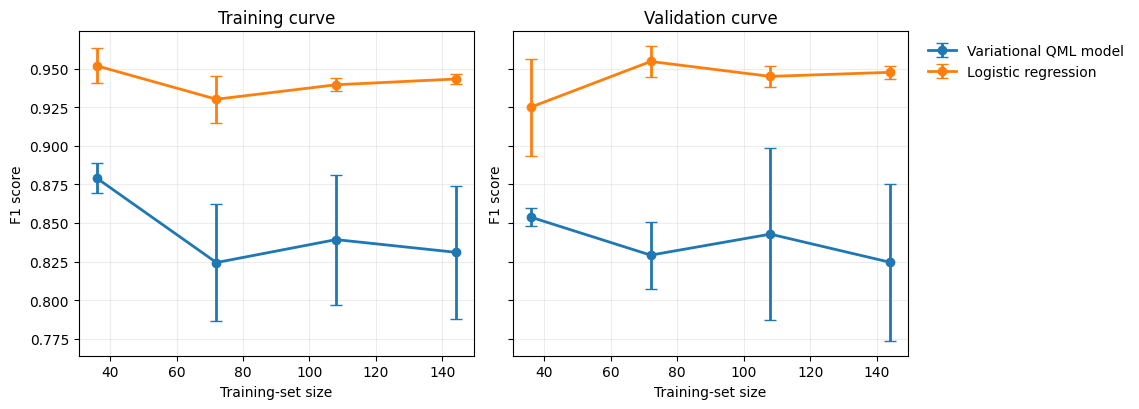

In [2]:
train_sizes_ex1 = [36, 72, 108, 144]
seeds_ex1 = [0, 1, 2]
model_specs_ex1 = [
    {'name': 'Variational QML model', 'kind': 'qml', 'encoding': 'angle_y', 'depth': 2, 'shots': None, 'epochs': 12, 'lr': 0.08},
    {'name': 'Logistic regression', 'kind': 'classical', 'estimator': LogisticRegression(max_iter=4000)},
]
rows_ex1 = run_learning_curve_study(train_sizes_ex1, seeds_ex1, model_specs_ex1, split_seed=11)
summary_ex1 = summarize_curve_rows(rows_ex1, metric='f1')
plot_learning_curve_summary(summary_ex1, model_order=['Variational QML model', 'Logistic regression'])

The two panels should be read together. In the training panel, the logistic-regression baseline stays above the variational QML model across all four training sizes, which indicates that, on this matched two-feature representation, the linear baseline fits the training data more effectively. In the validation panel, logistic regression also remains stronger and more stable, while the variational QML model stays lower and shows noticeably larger error bars, especially at the larger training sizes considered here. That larger spread means that the repeated runs are more sensitive to the seed and should be interpreted more cautiously.

Unlike the conceptual diagnostic figure, this case study separates the training and validation curves into two panels because the goal here is to compare two concrete models on the same matched representation rather than to sketch idealized regimes. In that comparison, there is no clear sample-efficiency gain for the variational model in this range of training sizes, the validation gap stays in favor of logistic regression, and the quantum model is more variable across seeds.

That does not mean that a variational QML model can never outperform logistic regression. It means only that such an advantage is not supported by this particular matched experiment. In other datasets, with different encodings, richer ansatz families, different classical baselines, or different resource budgets, the comparison may look different. The point of the example is therefore not to claim that the classical model should always win, but to show that QML should be judged by the same fair evaluation standard: if a quantum model is stronger, the learning curves should show it; if it is not stronger, that should also be reported plainly.


### Task 1 (coding): Compare the sample efficiency of two QML variants

Keep the same matched two-feature representation, but replace the original two-model comparison by a three-model study with two variational QML models and one classical baseline. In particular, compare the original QML model with `angle_y` encoding against a second QML model that uses a different encoding, and use logistic regression as the matched classical reference. The goal is to determine whether changing the encoding improves sample efficiency inside the QML family and whether that change narrows the validation gap to the classical baseline. To make that comparison more explicit, do not stop at plotting the curves: summarize the repeated validation curves numerically, compute a compact learning-curve summary for each model across the tested training sizes, and report how the validation gap between each QML variant and logistic regression changes as the training set grows.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="05-learning-curves-and-ablation-studies-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [3]:
# Task 1 starter
train_sizes_task1 = [36, 72, 108, 144]
seeds_task1 = [0, 1, 2, 3]
model_specs_task1 = [
    {'name': 'QML angle_y', 'kind': 'qml', 'encoding': 'angle_y', 'depth': 2, 'shots': None, 'epochs': 12, 'lr': 0.08},
    {'name': 'QML angle_yz', 'kind': 'qml', 'encoding': 'angle_yz', 'depth': 2, 'shots': None, 'epochs': 12, 'lr': 0.08},
    {'name': 'Logistic regression', 'kind': 'classical', 'estimator': LogisticRegression(max_iter=4000)},
]

# TODO:
# 1. run the learning-curve study for the two QML variants and logistic regression
# 2. aggregate repeated runs into mean and standard deviation of validation F1
# 3. make one figure that compares the validation curves with error bars
# 4. write a helper that computes the area under the mean validation learning curve
#    for each model across the tested training sizes
# 5. compute, at each training size, the validation-F1 gap between each QML variant
#    and logistic regression
# 6. decide whether changing the encoding improves QML sample efficiency and whether
#    it reduces the gap to the classical baseline consistently across training sizes


## Ablation studies as controlled comparisons

In a QML ablation study, one starts from a reference configuration and changes one factor at a time. The three factors considered here are the encoding choice $e$, the ansatz depth $L$, and the shot budget $N$. A configuration is therefore written as
$$
\omega=(e,L,N)
$$
If $a_{\mathrm{val}}^{(k)}(\omega)$ denotes a validation metric obtained for configuration $\omega$ in run $k$, then the mean and standard deviation across seeds are
$$
\bar a_{\mathrm{val}}(\omega)=\frac{1}{K}\sum_{k=1}^{K} a_{\mathrm{val}}^{(k)}(\omega), \qquad
\sigma_{\mathrm{val}}(\omega)=\sqrt{\frac{1}{K-1}\sum_{k=1}^{K}\left(a_{\mathrm{val}}^{(k)}(\omega)-\bar a_{\mathrm{val}}(\omega)\right)^2}
$$
When the exact-training reference is interpreted as $N=\infty$, the finite-shot penalty can be written as
$$
\delta_{\mathrm{shot}}(e,L,N)=\bar a_{\mathrm{val}}(e,L,\infty)-\bar a_{\mathrm{val}}(e,L,N)
$$
An ablation study is informative only when the non-ablated parts of the pipeline stay fixed.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>What must stay fixed in a valid ablation?</b> The dataset split should stay fixed so that different rows are not benefiting from easier or harder samples. The preprocessing logic should stay fixed so that the comparison reflects the ablated factor rather than a different data representation. The training budget and stopping rule should stay fixed so that one configuration is not simply receiving more optimization effort than another. The evaluation metric should also stay fixed so that the ranking is not changing only because success is being measured in a different way.</div>


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ablation-study-principle.png" alt="Ablation study principle" width="650"/>
</p>

## Example 2: Encoding-depth-shot ablations on one fixed split

The next example uses the same train-only preprocessing pipeline on one fixed split of the breast-cancer dataset. The ablation grid varies three encodings, three depths, and three shot budgets. Validation $F_1$ is then summarized in a panel of heatmaps, one panel per shot budget.

For finite-shot training, the exact score $s^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})$ is replaced during optimization by a shot-based estimator
$$
\hat s_{N}^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})
$$
which induces the probability estimate
$$
\hat p_{N}^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta}) = \frac{1+\hat s_{N}^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})}{2}
$$
and, for a batch $B \subset D_{\mathrm{train}}$, the shot-dependent empirical objective
$$
\mathcal{L}_{B,\mathrm{BCE}}^{(N)}(\boldsymbol{\theta}; e, L)
=
\frac{1}{|B|}\sum_{(\tilde{\vec{x}}^{\,j}, y^j)\in B}
c_{\mathrm{BCE}}\!\left(y^j, \hat p_{N}^{(e,L)}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})\right)
$$
Validation and test metrics are then still reported from the exact readout, so that the study isolates how finite-shot training changes the learned parameters rather than how finite-shot evaluation changes the reported score.


encoding                   depth    shots mean validation F1        std
-----------------------------------------------------------------------
Angle (RY-RY)                  1       32         0.7792     0.0229
Angle (RY-RY)                  1      128         0.7810     0.0269
Angle (RY-RY)                  1      512         0.7800     0.0216
Angle (RY-RY)                  2       32         0.8857     0.0599
Angle (RY-RY)                  2      128         0.8581     0.0110
Angle (RY-RY)                  2      512         0.8453     0.0071
Angle (RY-RY)                  3       32         0.9152     0.0169
Angle (RY-RY)                  3      128         0.8862     0.0159
Angle (RY-RY)                  3      512         0.8861     0.0079
Mixed-axis (RY-RZ)             1       32         0.7676     0.0000
Mixed-axis (RY-RZ)             1      128         0.7676     0.0000
Mixed-axis (RY-RZ)             1      512         0.7676     0.0000
Mixed-axis (RY-RZ)             2       3

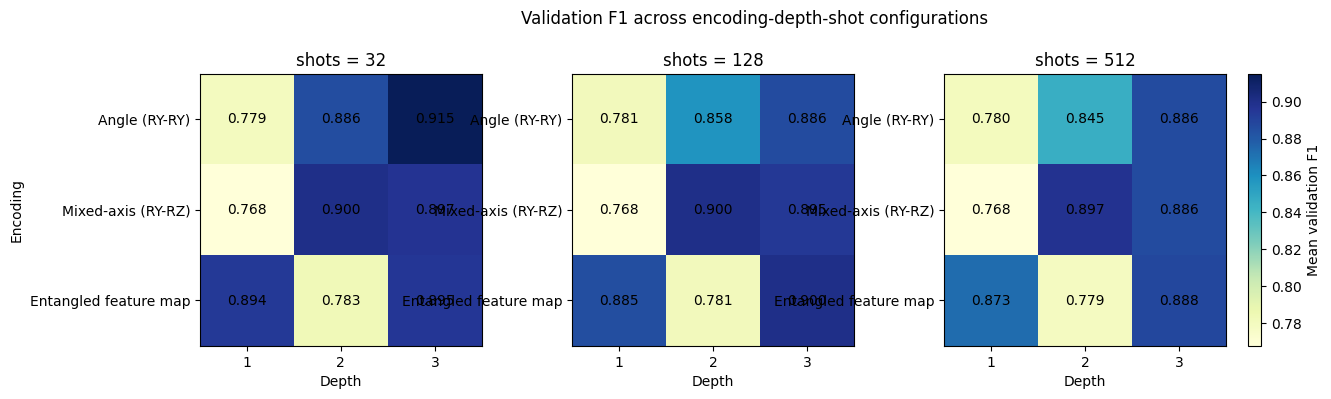

In [4]:
data_ablation = prepare_breast_cancer_representation(split_seed=11)
encodings_ex2 = ['angle_y', 'angle_yz', 'entangled']
depths_ex2 = [1, 2, 3]
shot_values_ex2 = [32, 128, 512]
seeds_ex2 = [0, 1]
rows_ex2 = run_ablation_grid(data_ablation, encodings=encodings_ex2, depths=depths_ex2, shot_values=shot_values_ex2, seeds=seeds_ex2, epochs=10, lr=0.08)
summary_ex2 = summarize_ablation_rows(rows_ex2, split='validation', metric='f1')
print_ablation_table(summary_ex2, mean_label='mean validation F1')
plot_ablation_panels(summary_ex2, encodings_ex2, depths_ex2, shot_values_ex2, 'Validation F1 across encoding-depth-shot configurations')


These panels and the table below should be read together. Within the `angle_y` and `angle_yz` rows, moving from depth `1` to depth `3` generally improves validation performance, and the strongest cells in those two encodings appear at the larger depths. The entangled feature map behaves differently: depth `1` and depth `3` remain competitive, while depth `2` is noticeably weaker across all three shot budgets. That contrast is exactly the kind of interaction that an ablation study is meant to reveal, because it shows that the effect of depth depends on which encoding is being used.

The shot dimension should also be read comparatively rather than in isolation. Some cells change only mildly as the shot budget increases, while others shift enough to change how attractive a configuration looks. In this example, the mixed-axis `angle_yz` encoding stays relatively strong across all three shot budgets, whereas other configurations are more sensitive to the chosen shot budget. The main lesson is that one should not summarize the grid with a single “winner” cell too quickly: the heatmaps show relative structure, and the printed table is useful for checking exact means and standard deviations before drawing a conclusion.


### Task 2 (coding): Quantify the penalty of finite-shot training

Augment the ablation study with an exact-training reference and then measure how much validation performance is lost when the optimizer uses only a finite shot budget. The goal is not only to compare finite-shot configurations with their matching exact counterparts, but also to detect which configurations are more robust to shot noise. To do that, summarize the shot penalties across the grid, define a sensitivity metric for each `(encoding, depth)` pair based on how far its finite-shot results move away from the exact reference, and use that metric to identify the most and least robust configurations.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="05-learning-curves-and-ablation-studies-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [5]:
# Task 2 starter
data_task2 = prepare_breast_cancer_representation(split_seed=11)
encodings_task2 = ['angle_y', 'angle_yz', 'entangled']
depths_task2 = [1, 2, 3]
shot_values_task2 = [None, 32, 128, 512]
seeds_task2 = [0, 1, 2]

# TODO:
# 1. run the ablation grid including the exact-training reference shots=None
# 2. summarize mean validation F1 for every configuration
# 3. compute the shot penalty relative to the matching exact configuration
# 4. make one figure with two panels:
#    left  = marginal mean validation F1 by shot budget for each depth
#    right = distribution of shot penalties for each finite shot budget
# 5. define a shot-sensitivity metric for each (encoding, depth) pair, for example
#    the mean absolute penalty across the finite shot budgets
# 6. rank the configurations by that sensitivity metric and identify which ones are
#    most robust and least robust to finite-shot training
# 7. explain whether the most robust configuration is also one of the strongest on
#    validation performance


## Beyond the best row: variability across seeds

A single ablation table often hides the fact that different seeds tell different stories. For a configuration $\omega$, the test-score summary across $K$ runs is
$$
\bar a_{\mathrm{test}}(\omega)=\frac{1}{K}\sum_{k=1}^{K} a_{\mathrm{test}}^{(k)}(\omega), \qquad
\sigma_{\mathrm{test}}(\omega)=\sqrt{\frac{1}{K-1}\sum_{k=1}^{K}\left(a_{\mathrm{test}}^{(k)}(\omega)-\bar a_{\mathrm{test}}(\omega)\right)^2}
$$
Reporting only the largest mean can therefore hide an important stability trade-off.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Stable evidence is stronger than a lucky seed.</b> If two configurations have nearly the same mean score but one has much larger standard deviation across seeds, the higher-variance option should be interpreted more cautiously.</div>

## Example 3: Mean performance versus variability across ablation configurations

The next example reruns a smaller ablation grid with more seeds and then plots each configuration in the plane mean test $F_1$ versus standard deviation of test $F_1$. Configurations near the upper-left corner are attractive because they combine stronger average performance with lower seed sensitivity.

Formally, a configuration $\omega$ is <a href="https://en.wikipedia.org/wiki/Pareto_efficiency">Pareto-efficient</a> in this plane if there is no other tested configuration $\omega'$ such that
$$
\bar a_{\mathrm{test}}(\omega') \geq \bar a_{\mathrm{test}}(\omega),
\qquad
\sigma_{\mathrm{test}}(\omega') \leq \sigma_{\mathrm{test}}(\omega)
$$
with at least one of those two inequalities strict. This criterion is useful because it distinguishes a configuration that is merely strong on average from one that is strong on average and not unnecessarily unstable.


encoding                   depth    shots   mean test F1        std
-------------------------------------------------------------------
Entangled feature map          1      128         0.8953     0.0124
Entangled feature map          1    exact         0.8867     0.0174
Entangled feature map          1      512         0.8867     0.0174
Entangled feature map          3      128         0.8819     0.0165
Entangled feature map          3      512         0.8767     0.0126
Entangled feature map          3    exact         0.8753     0.0103
Mixed-axis (RY-RZ)             2      128         0.8736     0.0289
Mixed-axis (RY-RZ)             3      128         0.8724     0.0160
Mixed-axis (RY-RZ)             3    exact         0.8701     0.0173
Mixed-axis (RY-RZ)             2      512         0.8692     0.0231
Angle (RY-RY)                  3    exact         0.8686     0.0101
Angle (RY-RY)                  3      512         0.8686     0.0101
Angle (RY-RY)                  3      128       

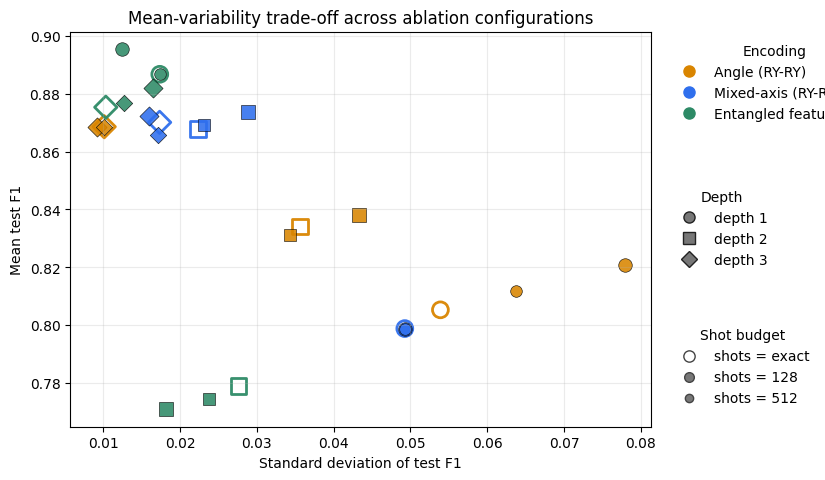

In [6]:
data_ex3 = prepare_breast_cancer_representation(split_seed=11)
rows_ex3 = run_ablation_grid(data_ex3, encodings=['angle_y', 'angle_yz', 'entangled'], depths=[1, 2, 3], shot_values=[None, 128, 512], seeds=[0, 1, 2, 3], epochs=10, lr=0.08)
summary_ex3 = summarize_ablation_rows(rows_ex3, split='test', metric='f1')
summary_ex3_sorted = sorted(summary_ex3, key=lambda row: (-row['mean'], row['std']))
print_ablation_table(summary_ex3_sorted, mean_label='mean test F1')
print('Best mean test F1:', max(summary_ex3, key=lambda row: row['mean']))
print('Smallest std of test F1:', min(summary_ex3, key=lambda row: row['std']))
plot_mean_std_tradeoff(summary_ex3)


The printed table should be used together with the scatter plot. The table gives the exact `(encoding, depth, shots)` identity, mean test $F_1$, and standard deviation for every point, while the plot shows the global geometry of the trade-off. In the scatter plot, color identifies the encoding family, marker shape identifies the depth, and marker size/style identifies the shot budget, with hollow markers used for the exact-training reference.

This representation makes it possible to see clusters and trade-offs without covering the figure with overlapping text labels. Configurations closer to the upper-left region remain attractive because they combine stronger mean test performance with lower seed-to-seed variability, but the table is what should be used to identify the exact rows once visually promising points have been located.


### Task 3 (coding): Which ablation conclusions remain stable across seeds?

Use repeated-seed summaries to distinguish a configuration that looks strongest on average from one that is also stable across runs. To do that, compare mean validation and test summaries, identify Pareto-efficient configurations in the plane mean test performance versus variability, and then check whether the configuration chosen only by the largest validation mean is also a robust reporting choice once seed sensitivity is taken into account.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="05-learning-curves-and-ablation-studies-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


In [7]:
# Task 3 starter
data_task3 = prepare_breast_cancer_representation(split_seed=11)
rows_task3 = run_ablation_grid(data_task3, encodings=['angle_y', 'angle_yz', 'entangled'], depths=[1, 2, 3], shot_values=[None, 128, 512], seeds=[0, 1, 2, 3, 4], epochs=10, lr=0.08)

# TODO:
# 1. summarize the repeated runs for both validation F1 and test F1
# 2. write a helper that returns the Pareto-efficient configurations in the plane
#    (std of test F1, mean of test F1), where lower std and higher mean are preferred
# 3. make one scatter plot with all configurations and highlight the Pareto frontier
# 4. identify the configuration with the highest mean validation F1
# 5. compare that configuration with the Pareto-efficient set
# 6. explain whether the validation winner is also a robust reporting choice

A final caution is important here. An ablation study of the form carried out above is local evidence: it shows how the conclusions change inside one fixed experimental pipeline, for one dataset, one family of encodings, one ansatz family, and one training protocol. Even when a particular setting looks best inside that local comparison, that does not establish a general advantage of QML over classical baselines, nor does it establish a universal superiority of one encoding, depth, or shot budget. Stronger claims require repeated evidence across datasets, preprocessing choices, model families, and evaluation protocols.


## Key takeaways

- Learning curves help distinguish underfitting, overfitting, and data scarcity.
- An ablation study is only interpretable when the non-ablated parts of the pipeline stay fixed.
- Encoding choice, depth, and shot budget can interact strongly in QML.
- Mean performance and seed-to-seed variability should be reported together whenever possible.